In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import json
import torch
import os
import copy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import multilabel_confusion_matrix, classification_report, roc_curve, auc, confusion_matrix, \
     RocCurveDisplay, precision_score, recall_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score
from tqdm import tqdm
from matplotlib.pyplot import figure


In [2]:
from matplotlib import rc, rcParams
rc('axes', linewidth=1)
rc('font', size=7)
plt.rcParams['font.family'] = 'Arial'

In [87]:
from matplotlib import rc, rcParams
rc('axes', linewidth=1)
rc('font', size=7)
plt.rcParams['font.family'] = 'Arial'

def read_csv(filename):
    return pd.read_csv(filename)

# AUC ROC

def roc_auc_scores(y_true, y_pred, features):
    # n_classes = y_true.shape[1]

    tpr = dict()
    fpr = dict()
    auc_scores = dict()
    thresholds = dict()
        
    for i, fea in enumerate(features):
        y_true_ = np.array(y_true[:, i])
        y_pred_ = np.array(y_pred[:, i])
        mask = np.array([1 if not np.isnan(k) else 0 for k in y_true_])
        masked_y_true = y_true_[np.where(mask == 1)]
        masked_y_pred = y_pred_[np.where(mask == 1)]
        fpr[fea], tpr[fea], thresholds[fea] = roc_curve(y_true=masked_y_true, y_score=masked_y_pred, pos_label=1, drop_intermediate=False)
        auc_scores[fea] = auc(fpr[fea], tpr[fea])

    return fpr, tpr, auc_scores, thresholds

def generate_roc(y_true, y_pred, features, subgroup, fname):
    fpr, tpr, auc_scores, _ = roc_auc_scores(y_true=y_true, y_pred=y_pred, features=features)
    lw = 1
    
    custom_labels = {'amy_label': 'Amyloid', 'tau_label': 'Tau'}
    
    # Initialize a DataFrame to store all the data for plotting
    all_data = pd.DataFrame()

    # Generate interpolated data for each feature
    for feature in features:
        fpr_value = np.linspace(0, 1, 100)
        interp_tpr = np.interp(fpr_value, fpr[feature], tpr[feature])
        temp_df = pd.DataFrame({
            'Specificity': 1 - fpr_value,
            'Sensitivity': interp_tpr,
            'Feature': '{0}: {1:0.2f}'.format(custom_labels[feature], auc_scores[feature])
        })
        all_data = pd.concat([all_data, temp_df])
        if "amy" in feature:
            perf_dict_amy[subgroup][fname]['AUROC'] = round(auc_scores[feature], 2)
        else:
            perf_dict_tau[subgroup][fname]['AUROC'] = round(auc_scores[feature], 2)


# P-R curve

def precision_recall(y_true, y_pred, features):
    # Compute the precision-recall curve and average precision for each class
    # n_classes = y_true.shape[1]
    precision = dict()
    recall = dict()
    average_precision = dict()
    for i, fea in enumerate(features):
        y_true_ = np.array(y_true[:, i])
        y_pred_ = np.array(y_pred[:, i])
        mask = np.array([1 if not np.isnan(k) else 0 for k in y_true_])
        masked_y_true = y_true_[np.where(mask == 1)]
        masked_y_pred = y_pred_[np.where(mask == 1)]
        
        precision[fea], recall[fea], _ = precision_recall_curve(masked_y_true, masked_y_pred)
        precision[fea], recall[fea] = precision[fea][::-1], recall[fea][::-1]
        average_precision[fea] = average_precision_score(masked_y_true, masked_y_pred)

    return precision, recall, average_precision


def generate_pr(y_true, y_pred, features, subgroup, fname):
    precision, recall, average_precision = precision_recall(y_true=y_true, y_pred=y_pred, features=features)
    lw = 1
    custom_labels = {'amy_label': 'Amyloid', 'tau_label': 'Tau'}
    
    # Initialize a DataFrame to store all the data for plotting
    all_data = pd.DataFrame()

    # Generate interpolated data for each feature
    for feature in features:
        mean_recall = np.linspace(0, 1, 100)
        interp_precision = np.interp(mean_recall, recall[feature], precision[feature])
        temp_df = pd.DataFrame({
            'Recall': mean_recall,
            'Precision': interp_precision,
            'Feature': '{0}: {1:0.2f}'.format(custom_labels[feature], average_precision[feature])  # This column will be used for hue in the plot
        })
        all_data = pd.concat([all_data, temp_df])
        if "amy" in feature:
            perf_dict_amy[subgroup][fname]['AUPR'] = round(average_precision[feature], 2)
        else:
            perf_dict_tau[subgroup][fname]['AUPR'] = round(average_precision[feature], 2)



In [88]:
cog_labels = ['amy_label', 'tau_label']

## heatmap

In [123]:
basedir = "./source_data/efig1"
efig1a_female = f"{basedir}/efig1b_female.csv"
efig1a_male = f"{basedir}/efig1b_male.csv"
efig1a_whi = f"{basedir}/efig1c_whi.csv"
efig1a_oth = f"{basedir}/efig1c_oth.csv"
efig1a_age_above_median = f"{basedir}/efig1a_age_above_median.csv"
efig1a_age_below_median = f"{basedir}/efig1a_age_below_median.csv"

In [124]:
def roc_pr(sub_df, fname, subgroup):
    pred = pd.read_csv(sub_df)
    y_true_ =  np.array(pred[[f'{lab}_label' for lab in cog_labels]])
    scores_proba_ = np.array(pred[[f'{lab}_prob' for lab in cog_labels]])
    
    generate_roc(y_true_, scores_proba_, cog_labels, subgroup, fname)
    generate_pr(y_true_, scores_proba_, cog_labels, subgroup, fname)

In [125]:
perf_dict_amy = {"sex": {"male": {}, "female": {}}, "age": {"age_above_median": {}, "age_below_median": {}}, "race": {"whi": {}, "oth": {}}}
perf_dict_tau = {"sex": {"male": {}, "female": {}}, "age": {"age_above_median": {}, "age_below_median": {}}, "race": {"whi": {}, "oth": {}}}

In [126]:
roc_pr(efig1a_female, "female", "sex")
roc_pr(efig1a_male, "male", "sex")
roc_pr(efig1a_whi, "whi", "race")
roc_pr(efig1a_oth, "oth", "race")
roc_pr(efig1a_age_above_median, "age_above_median", "age")
roc_pr(efig1a_age_below_median, "age_below_median", "age")

In [127]:
rows = []
for subgroup, categories in perf_dict_amy.items():
    for category, metrics in categories.items():
        rows.append({'Subgroup': subgroup, 'Category': category, 'AUROC': metrics['AUROC'], 'AUPR': metrics['AUPR'], "Label" : "amy_label"})

df1 = pd.DataFrame(rows)

rows = []
for subgroup, categories in perf_dict_tau.items():
    for category, metrics in categories.items():
        rows.append({'Subgroup': subgroup, 'Category': category, 'AUROC': metrics['AUROC'], 'AUPR': metrics['AUPR'], "Label" : "tau_label"})

df2 = pd.DataFrame(rows)

data = pd.concat([df1, df2], axis=0).reset_index(drop=True)

In [128]:
data

,Subgroup,Category,AUROC,AUPR,Label
0,sex,male,0.82,0.80,amy_label
1,sex,female,0.82,0.84,amy_label
2,age,age_above_median,0.82,0.82,amy_label
3,age,age_below_median,0.81,0.81,amy_label
4,race,whi,0.82,0.82,amy_label
5,race,oth,0.85,0.80,amy_label
6,sex,male,0.73,0.37,tau_label
7,sex,female,0.81,0.68,tau_label
8,age,age_above_median,0.73,0.44,tau_label
9,age,age_below_median,0.79,0.61,tau_label


## Sex

In [135]:
fontsize = 16

In [136]:
df = data[data['Subgroup'] == "sex"].drop(['Subgroup'], axis=1, inplace=False).reset_index(drop=True)

In [137]:
# amy
amy = df[df['Label'] == 'amy_label']
amy.drop(columns=['Label'], inplace = True)
amy.set_index('Category', inplace=True)

#tau 
tau = df[df['Label'] == 'tau_label']
tau.drop(columns=['Label'], inplace = True)
tau.set_index('Category', inplace=True)

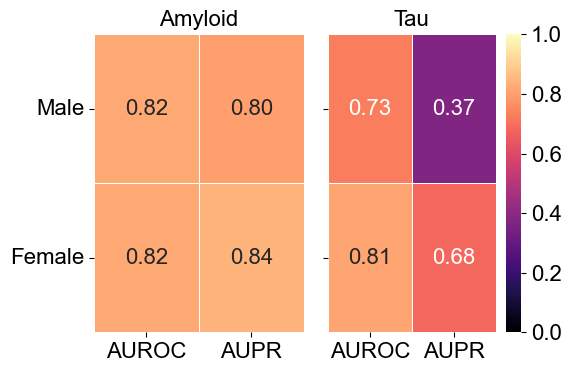

In [138]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = fontsize


vmin = 0
vmax = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# Group names
group_names = ["Male", "Female"]

# Plotting amyloid heatmap
sns.heatmap(amy, ax=axes[0], annot=True, cmap='magma', fmt=".2f", cbar=False, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[0].set_title('Amyloid', fontname='Arial', fontsize=fontsize)
axes[0].set_yticklabels(group_names, rotation=0)  # Set group names
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Plotting tau heatmap
sns.heatmap(tau, ax=axes[1], annot=True, cmap='magma', fmt=".2f", cbar_kws={'label': ''}, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[1].set_title('Tau', fontname='Arial', fontsize=fontsize)
axes[1].set_yticklabels(group_names, rotation=0)  # Set group names
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(f'./pdf_plots/figEF1b.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()


## Race

In [139]:
df = data[data['Subgroup'] == "race"].drop(['Subgroup'], axis=1, inplace=False)

In [140]:
# amy
amy = df[df['Label'] == 'amy_label']
amy.drop(columns=['Label'], inplace = True)
amy.set_index('Category', inplace=True)

#tau 
tau = df[df['Label'] == 'tau_label']
tau.drop(columns=['Label'], inplace = True)
tau.set_index('Category', inplace=True)

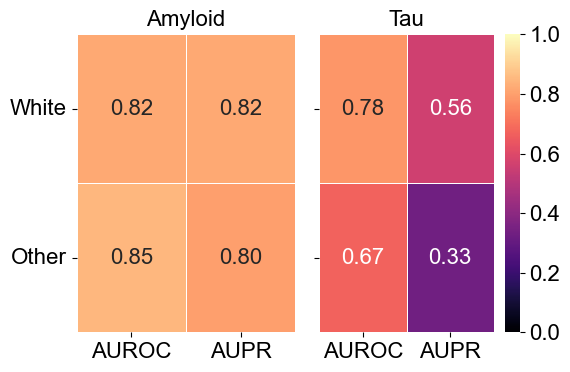

In [141]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = fontsize


vmin = 0
vmax = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# Group names
group_names = ["White", "Other"]

# Plotting amyloid heatmap
sns.heatmap(amy, ax=axes[0], annot=True, cmap='magma', fmt=".2f", cbar=False, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[0].set_title('Amyloid', fontname='Arial', fontsize=fontsize)
axes[0].set_yticklabels(group_names, rotation=0)  # Set group names
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Plotting tau heatmap
sns.heatmap(tau, ax=axes[1], annot=True, cmap='magma', fmt=".2f", cbar_kws={'label': ''}, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[1].set_title('Tau', fontname='Arial', fontsize=fontsize)
axes[1].set_yticklabels(group_names, rotation=0)  # Set group names
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(f'./pdf_plots/figEF1c.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()


## Age

In [142]:
df = data[data['Subgroup'] == "age"].drop(['Subgroup'], axis=1, inplace=False)

In [143]:
# amy
amy = df[df['Label'] == 'amy_label']
amy.drop(columns=['Label'], inplace = True)
amy.set_index('Category', inplace=True)

#tau 
tau = df[df['Label'] == 'tau_label']
tau.drop(columns=['Label'], inplace = True)
tau.set_index('Category', inplace=True)

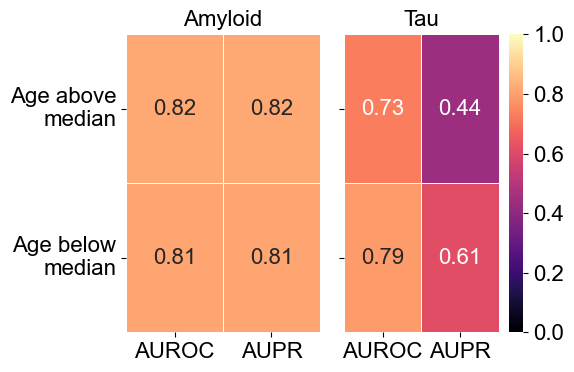

In [144]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = fontsize


vmin = 0
vmax = 1

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# Group names
group_names = ["Age above\nmedian", "Age below\nmedian"]

# Plotting amyloid heatmap
sns.heatmap(amy, ax=axes[0], annot=True, cmap='magma', fmt=".2f", cbar=False, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[0].set_title('Amyloid', fontname='Arial', fontsize=fontsize)
axes[0].set_yticklabels(group_names, rotation=0)  # Set group names
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Plotting tau heatmap
sns.heatmap(tau, ax=axes[1], annot=True, cmap='magma', fmt=".2f", cbar_kws={'label': ''}, linewidths=.5, annot_kws={"size": fontsize}, vmin=vmin, vmax=vmax)
axes[1].set_title('Tau', fontname='Arial', fontsize=fontsize)
axes[1].set_yticklabels(group_names, rotation=0)  # Set group names
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(f'./pdf_plots/figEF1a.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()
